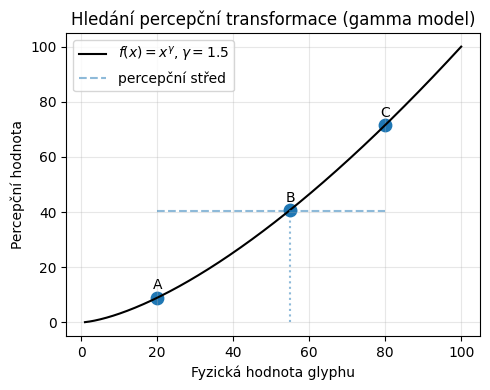

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# UKÁZKOVÝ JEDEN TRIAL
# -----------------------------
A = 20
C = 80
B_user = 55        # subjektivně zvolený střed
gamma = 1.5

# percepční transformace
def f(x):
    return 100 * (x / 100.0) ** gamma

# ideální percepční střed
f_mid = 0.5 * (f(A) + f(C))

# osa
x = np.linspace(1, 100, 400)

# -----------------------------
# GRAF
# -----------------------------
plt.figure(figsize=(5, 4))

# gamma křivka
plt.plot(x, f(x), color="black", label=r"$f(x)=x^\gamma, \gamma=1.5$")

# A, B, C
plt.scatter([A, B_user, C],
            [f(A), f(B_user), f(C)],
            s=80)

# pomocné čáry (vysvětlení středu)
plt.hlines(f_mid, A, C, linestyles="dashed", alpha=0.5,
           label="percepční střed")
plt.vlines(B_user, 0, f(B_user), linestyles="dotted", alpha=0.5)

# popisky
plt.text(A, f(A)+3, "A", ha="center")
plt.text(B_user, f(B_user)+3, "B", ha="center")
plt.text(C, f(C)+3, "C", ha="center")

plt.xlabel("Fyzická hodnota glyphu")
plt.ylabel("Percepční hodnota")
plt.title("Hledání percepční transformace (gamma model)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# export
plt.savefig("gamma_perception_example.svg")
plt.savefig("gamma_perception_example.pdf", dpi=300)

plt.show()


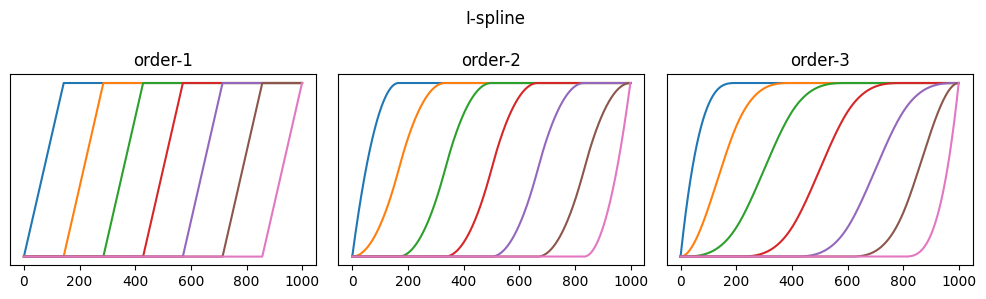

In [2]:
"""
Python code to generate M-splines and I-splines.
References
----------
Ramsay, J. O. (1988). Monotone regression splines in action.
Statistical science, 3(4), 425-441.
"""

import numpy as np
import matplotlib.pyplot as plt

def mspline_grid(order, num_basis_funcs, nt):
    """
    Generate a set of M-spline basis functions with evenly
    spaced knots.
    Parameters
    ----------
    order : int
        Order parameter of the splines.
    num_basis_funcs : int
        Number of desired basis functions. Note that we
        require num_basis_funcs >= order.
    nt : int
        Number of points to evaluate the basis functions.
    Returns
    -------
    spine_basis : array
        Matrix with shape (num_basis_funcs, nt), holding the
        desired spline basis functions.
    """

    # Determine number of interior knots.
    num_interior_knots = num_basis_funcs - order
    
    if num_interior_knots < 0:
        raise ValueError(
            "Spline `order` parameter cannot be larger "
            "than `num_basis_funcs` parameter."
        )

    # Fine grid of numerically evaluated points.
    x = np.linspace(0, 1 - 1e-6, nt)

    # Set of spline knots. We need to add extra knots to
    # the end to handle boundary conditions for higher-order
    # spline bases. See Ramsay (1988) cited above.
    #
    # Note - this is poorly explained on most corners of the
    # internet that I've found.
    knots = np.concatenate((
        np.zeros(order - 1),
        np.linspace(0, 1, num_interior_knots + 2),
        np.ones(order - 1),
    ))

    # Evaluate and stack each basis function.
    return np.vstack(
        [mspline(x, order, i, knots) for i in range(num_basis_funcs)]
    )

def mspline(x, k, i, T):
    """
    Compute M-spline basis function `i` at points `x` for a spline
    basis of order-`k` with knots `T`.
    Parameters
    ----------
    x : array
        Vector holding points to evaluate the spline.
    """

    # Boundary conditions.
    if (T[i + k] - T[i]) < 1e-6:
        return np.zeros_like(x)

    # Special base case of first-order spline basis.
    elif k == 1:
        v = np.zeros_like(x)
        v[(x >= T[i]) & (x < T[i + 1])] = 1 / (T[i + 1] - T[i])
        return v

    # General case, defined recursively
    else:
        return k * (
            (x - T[i]) * mspline(x, k - 1, i, T)
            + (T[i + k] - x) * mspline(x, k - 1, i + 1, T)
        ) / ((k-1) * (T[i + k] - T[i]))

    
def ispline_grid(order, num_basis_funcs, nt):
    """
    Generate a set of I-spline basis functions with evenly
    spaced knots.
    Parameters
    ----------
    order : int
        Order parameter of the splines.
    num_basis_funcs : int
        Number of desired basis functions. Note that we
        require num_basis_funcs >= order.
    nt : int
        Number of points to evaluate the basis functions.
    Returns
    -------
    spine_basis : array
        Matrix with shape (num_basis_funcs, nt), holding the
        desired spline basis functions.
    """

    # Determine number of interior knots.
    num_interior_knots = num_basis_funcs - order
    
    if num_interior_knots < 0:
        raise ValueError(
            "Spline `order` parameter cannot be larger "
            "than `num_basis_funcs` parameter."
        )

    # Fine grid of numerically evaluated points.
    x = np.linspace(0, 1 - 1e-6, nt)

    # Set of spline knots. We need to add extra knots to
    # the end to handle boundary conditions for higher-order
    # spline bases. See Ramsay (1988) cited above.
    #
    # Note - this is poorly explained on most corners of the
    # internet that I've found.
    knots = np.concatenate((
        np.zeros(order),
        np.linspace(0, 1, num_interior_knots + 2),
        np.ones(order),
    ))

    # Evaluate and stack each basis function.
    return np.vstack(
        [ispline(x, order, i, knots) for i in range(num_basis_funcs)]
    )

def ispline(x, k, i, T):
    """
    Compute I-spline basis function `i` at points `x` for a spline
    basis of order-`k` with knots `T`.
    Parameters
    ----------
    x : array
        Vector holding points to evaluate the spline.
    """

    # index j where t_j ≤ x < t_{j+1}
    i += 1
    j = np.array([np.argwhere(T <= xi)[-1, 0] if T[0] <= xi else -1 for xi in x])

    # Boundary conditions
    v = np.zeros_like(x)
    v[j-k+1 > i] = 1
    
    # General case, defined by M-spline
    j_valid = j[(j-k+1 <= i) & (i <= j)]
    x_valid = x[(j-k+1 <= i) & (i <= j)]
    
    # (T[i+k] - t[i-1])  ~  (T[j+k] - t[j-1])
    Tms = [T[(i+k+1):(j_+k+1+1)] - T[i:(j_+1)] for j_ in j_valid]
    
    # M_i(x|k+1,t)  ~  M_j(x|k+1,t)
    Mms = [np.array([mspline(x_, k+1, m, T) for m in range(i, j_+1)]) \
           for x_, j_ in zip(x_valid, j_valid)]
    
    v[(j-k+1 <= i) & (i <= j)] = [(Tm * Mm).sum()/(k+1) for Tm, Mm in zip(Tms, Mms)]
        
    return v

# Test code
if __name__ == "__main__":
    # Plot basis funcs, varying the order parameter.
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    for k, ax in enumerate(axes):
        order = k + 1
        # I-spline
        ax.plot(ispline_grid(order, 7, 1000).T)
        # # M-spline
        # ax.plot(mspline_grid(order, 7, 1000).T)
        ax.set_yticks([])
        ax.set_title(f"order-{order}")
    plt.suptitle("I-spline")
    fig.tight_layout()
    plt.show()

Parametry z = [0.5 0.5 1.  2. ]
Uzlové hodnoty yk = [0.         0.04545455 0.09090909 0.27272727 1.        ]


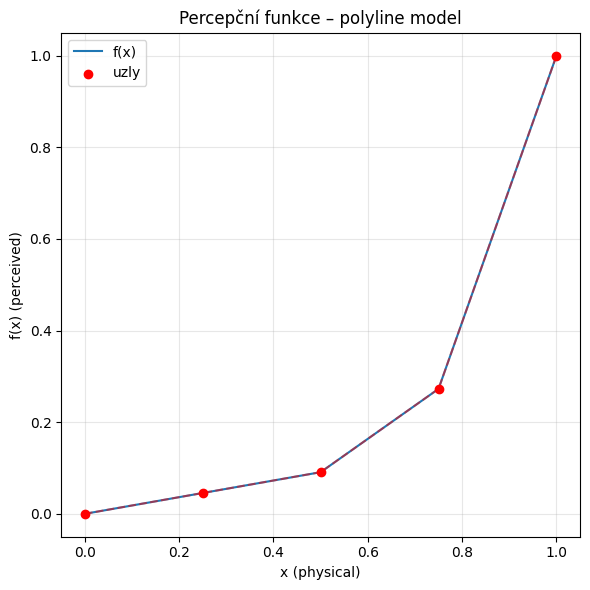

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# pevné uzly
XK = np.array([0.0, 0.25, 0.5, 0.75, 1.0], float)

def params_to_yk(z):
    z = np.asarray(z, float)
    d = z*z                    # nezáporné přírůstky
    S = np.sum(d) + 1e-12

    y1 = d[0] / S
    y2 = (d[0] + d[1]) / S
    y3 = (d[0] + d[1] + d[2]) / S

    yk = np.array([0.0, y1, y2, y3, 1.0], float)
    return yk

def make_f_polyline(z):
    yk = params_to_yk(z)

    def f(x):
        x = np.clip(np.asarray(x, float), 0.0, 1.0)
        return np.interp(x, XK, yk)

    return f, yk


# ---------- TEST ----------
z = np.array([0.5, 0.5, 1, 2])   # zkus pak měnit

f, yk = make_f_polyline(z)

print("Parametry z =", z)
print("Uzlové hodnoty yk =", yk)

x = np.linspace(0, 1, 400)
y = f(x)

plt.figure(figsize=(6,6))
plt.plot(x, y, label="f(x)")
plt.scatter(XK, yk, color="red", zorder=3, label="uzly")
plt.plot(XK, yk, color="red", linestyle="--", alpha=0.5)
plt.xlabel("x (physical)")
plt.ylabel("f(x) (perceived)")
plt.title("Percepční funkce – polyline model")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


===== DEBUG ONE TRIAL =====
z = [1.  0.5 1.  0.5]
XK = [0.   0.25 0.5  0.75 1.  ]
yk = [0.  0.4 0.5 0.9 1. ]

A = 0.200000  -> f(A) = 0.355520
C = 0.800000  -> f(C) = 0.930880
target = (f(A)+f(C))/2 = 0.643200

Inverze přes mřížku:
  idx = 2389
  y leží mezi y0=0.642734 a y1=0.643237
  odpovídá x0=0.597149 a x1=0.597399
  t = 0.927215  (relativní pozice v intervalu)

B_pred = 0.597381


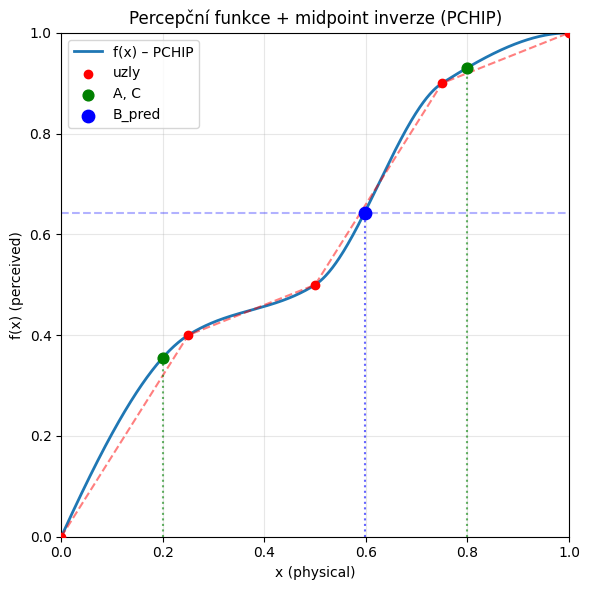

In [20]:
import numpy as np
import matplotlib.pyplot as plt


XK = np.array([0.0, 0.25, 0.5, 0.75, 1.0], float)

def params_to_yk(z):
    z = np.asarray(z, float)
    if z.shape[0] != 4:
        raise ValueError("z musí mít délku 4: [z1, z2, z3, z4]")

    d = z*z
    S = np.sum(d) + 1e-12

    y0 = 0.0
    y1 = d[0] / S
    y2 = (d[0] + d[1]) / S
    y3 = (d[0] + d[1] + d[2]) / S
    y4 = 1.0

    return np.array([y0, y1, y2, y3, y4], float)


def make_f_polyline(z):
    yk = params_to_yk(z)
    def f(x):
        x = np.clip(np.asarray(x, float), 0.0, 1.0)
        return np.interp(x, XK, yk)
    return f, yk

def invert_monotone_f_debug(f, y, grid_n=4000):
    y = float(y)
    xg = np.linspace(0.0, 1.0, grid_n)
    yg = f(xg)

    idx = int(np.searchsorted(yg, y, side="left"))
    idx = int(np.clip(idx, 1, grid_n - 1))

    x0, x1 = float(xg[idx-1]), float(xg[idx])
    y0, y1 = float(yg[idx-1]), float(yg[idx])

    if abs(y1 - y0) > 1e-12:
        t = (y - y0) / (y1 - y0)
    else:
        t = 0.0

    x = x0 + t * (x1 - x0)

    debug = dict(
        idx=idx,
        x0=x0, x1=x1,
        y0=y0, y1=y1,
        t=t
    )
    return float(x), debug

from scipy.interpolate import PchipInterpolator

def make_f_pchip(z):
    yk = params_to_yk(z)  # stejné jako doteď: [0, y1, y2, y3, 1]

    interp = PchipInterpolator(XK, yk, extrapolate=True)

    def f(x):
        x = np.clip(np.asarray(x, float), 0.0, 1.0)
        return np.clip(interp(x), 0.0, 1.0)

    return f, yk


def debug_one_trial(z, A, C, grid_n=4000):
    f, yk = make_f_pchip(z)

    pA = float(f(A))
    pC = float(f(C))
    target = 0.5 * (pA + pC)

    B_pred, dbg = invert_monotone_f_debug(f, target, grid_n=grid_n)

    # ---------- PRINT ----------
    print("===== DEBUG ONE TRIAL =====")
    print("z =", np.asarray(z, float))
    print("XK =", XK)
    print("yk =", yk)
    print()
    print(f"A = {A:.6f}  -> f(A) = {pA:.6f}")
    print(f"C = {C:.6f}  -> f(C) = {pC:.6f}")
    print(f"target = (f(A)+f(C))/2 = {target:.6f}")
    print()
    print("Inverze přes mřížku:")
    print(f"  idx = {dbg['idx']}")
    print(f"  y leží mezi y0={dbg['y0']:.6f} a y1={dbg['y1']:.6f}")
    print(f"  odpovídá x0={dbg['x0']:.6f} a x1={dbg['x1']:.6f}")
    print(f"  t = {dbg['t']:.6f}  (relativní pozice v intervalu)")
    print()
    print(f"B_pred = {B_pred:.6f}")
    print("===========================")

    # ---------- PLOT ----------
    x = np.linspace(0, 1, 600)
    y = f(x)

    plt.figure(figsize=(6, 6))

    # percepční křivka
    plt.plot(x, y, label="f(x) – PCHIP", lw=2)

    # uzly
    plt.scatter(XK, yk, color="red", zorder=3, label="uzly")
    plt.plot(XK, yk, color="red", linestyle="--", alpha=0.5)

    # A, C
    plt.scatter([A, C], [pA, pC], color="green", s=60, zorder=4, label="A, C")
    plt.plot([A, A], [0, pA], color="green", linestyle=":", alpha=0.6)
    plt.plot([C, C], [0, pC], color="green", linestyle=":", alpha=0.6)

    # percepční střed
    plt.scatter([B_pred], [target], color="blue", s=80, zorder=5, label="B_pred")
    plt.plot([B_pred, B_pred], [0, target], color="blue", linestyle=":", alpha=0.6)

    # pomocná vodorovná čára pro target
    plt.axhline(target, color="blue", linestyle="--", alpha=0.3)

    plt.xlabel("x (physical)")
    plt.ylabel("f(x) (perceived)")
    plt.title("Percepční funkce + midpoint inverze (PCHIP)")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# --------- SEM DOSAĎ SVŮJ JEDEN PŘÍKLAD ---------
z = [1.0, 0.5, 1.0, 0.5]
A = 0.20
C = 0.80

debug_one_trial(z, A, C, grid_n=4000)
